In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/train.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.zip
/kaggle/input/test_tfrecords.zip
/kaggle/input/train_tfrecords.zip
/kaggle/input/test_images.zip
/kaggle/input/train.csv
/kaggle/input/train.zip
/kaggle/input/description.md
/kaggle/input/train_images.zip
/kaggle/input/sample_submission.csv
/kaggle/input/label_num_to_disease_map.json
/kaggle/input/test_images/2574872277.jpg
/kaggle/input/test_images/1449210447.jpg
/kaggle/input/test_images/1269550303.jpg
/kaggle/input/test_images/1411799307.jpg
/kaggle/input/test_images/2474336811.jpg
/kaggle/input/test_images/2513489893.jpg
/kaggle/input/test_images/138763396.jpg
/kaggle/input/test_images/1454379342.jpg
/kaggle/input/test_images/135606795.jpg
/kaggle/input/test_images/244091101.jpg
/kaggle/input/test_images/1305931861.jpg
/kaggle/input/test_images/2431640165.jpg
/kaggle/input/test_images/262767997.jpg
/kaggle/input/test_images/2562280265.jpg
/kaggle/input/test_images/1249688756.jpg
/kaggle/input

In [2]:
from fastai.vision.all import * 
from fastai import * 
import pandas as pd 
import numpy as np

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
train_data = Path('../input/cassava-leaf-disease-classification/train_images')
test_data = Path('../input/cassava-leaf-disease-classification/test_images')


In [4]:
# Getting the labels 

df = pd.read_csv('../input/cassava-leaf-disease-classification/train.csv')
df

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
...,...,...
18716,999068805.jpg,3
18717,999329392.jpg,3
18718,999474432.jpg,1
18719,999616605.jpg,4


In [5]:
# Getting the filenames 

fns_train = get_image_files(train_data)
fns_test = get_image_files(test_data)

len(fns_train) , len(fns_test)

(18721, 2676)

In [6]:
fns_train

(#18721) [Path('../input/cassava-leaf-disease-classification/train_images/478676678.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/2315755156.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/2869465595.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/291787943.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/3310982329.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/3556578053.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/4278159410.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/3122760139.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/2323728288.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/2922394453.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/3722449524.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/619953066.jpg'),Path('../input/cassav

In [7]:
# Transforms 

item_tfms = RandomResizedCrop(460, min_scale=0.75),
batch_tfms = [*aug_transforms(size=224, max_warp=0 , max_zoom= 0.8 ), Normalize.from_stats(*imagenet_stats)]

In [8]:
# Building a DataBlock 


cassava = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   get_x=ColReader(0, pref=train_data),
                   splitter=RandomSplitter(),
                   get_y=ColReader(1),
                   item_tfms = item_tfms,
                   batch_tfms = batch_tfms ) 

In [9]:
cassava.summary(df)

Setting-up type transforms pipelines
0      1000015157.jpg      0
1      1000201771.jpg      3
2       100042118.jpg      1
3      1000723321.jpg      1
4      1000812911.jpg      3
...               ...    ...
18716   999068805.jpg      3
18717   999329392.jpg      3
18718   999474432.jpg      1
18719   999616605.jpg      4
18720   999998473.jpg      4

[18721 rows x 2 columns]
Found 18721 items
2 datasets of sizes 14977,3744
Setting up Pipeline: ColReader -- {'cols': 0, 'pref': Path('../input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 -> PILBase.create
Setting up Pipeline: ColReader -- {'cols': 1, 'pref': '', 'suff': '', 'label_delim': None}
 -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)



Building one sample
  Pipeline: ColReader -- {'cols': 0, 'pref': Path('../input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 -> PILBase.create
    starting from
      image_id    3812804387.jpg
label                    3
Name: 12971, dtype: object
    applying ColReader -- {'cols': 0, 'pref': Path('../input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 gives
      ../input/cassava-leaf-disease-classification/train_images/3812804387.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=800x600
  Pipeline: ColReader -- {'cols': 1, 'pref': '', 'suff': '', 'label_delim': None}
 -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      image_id    3812804387.jpg
label                    3
Name: 12971, dtype: object
    applying ColReader -- {'cols': 1, 'pref': '', 'suff': '', 'label_delim': None}
 gives
      3
    applying Categorize -- {'vocab': None, 'sort': True,

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 


Building one batch
Applying item_tfms to the first sample:
  Pipeline: RandomResizedCrop -- {'size': (460, 460), 'min_scale': 0.75, 'ratio': (0.75, 1.3333333333333333), 'resamples': (<Resampling.BILINEAR: 2>, <Resampling.NEAREST: 0>), 'val_xtra': 0.14, 'max_scale': 1.0, 'p': 1.0}
 -> ToTensor
    starting from
      (PILImage mode=RGB size=800x600, TensorCategory(3))
    applying RandomResizedCrop -- {'size': (460, 460), 'min_scale': 0.75, 'ratio': (0.75, 1.3333333333333333), 'resamples': (<Resampling.BILINEAR: 2>, <Resampling.NEAREST: 0>), 'val_xtra': 0.14, 'max_scale': 1.0, 'p': 1.0}
 gives
      (PILImage mode=RGB size=460x460, TensorCategory(3))
    applying ToTensor gives
      (TensorImage of size 3x460x460, TensorCategory(3))

Adding the next 3 samples

No before_batch transform to apply

Collating items in a batch

Applying batch_tfms to the batch built
  Pipeline: IntToFloatTensor -- {'div': 255.0, 'div_mask': 1}
 -> Flip -- {'size': 224, 'mode': 'bilinear', 'pad_mode': 'refl

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


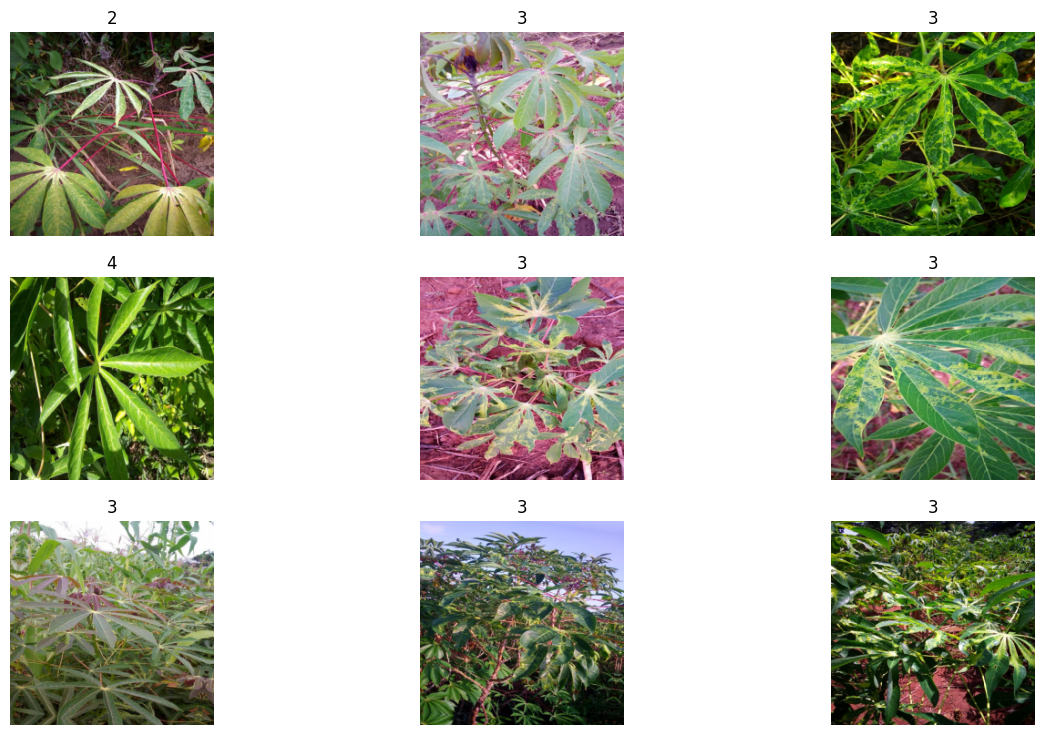

In [10]:
# Putting into a dataloader 

train_dls = cassava.dataloaders(df , bs = 32)
train_dls.show_batch(figsize = (15 , 9))

In [11]:

# Creating a learner 

# learn = cnn_learner(train_dls , alexnet  , metrics = [error_rate , accuracy] , pretrained = False )

In [12]:
learn_inf = load_learner('../input/cassava-model-vgg/export(1).pkl', cpu = False)
learn_inf

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


FileNotFoundError: [Errno 2] No such file or directory: '../input/cassava-model-vgg/export(1).pkl'

In [13]:
# Creating a test dataloader 

test_dl = train_dls.test_dl(fns_test)

In [14]:
# Getting predictions with inference 
test_pred = learn_inf.get_preds(dl = test_dl)
test_pred

NameError: name 'learn_inf' is not defined

In [15]:
# Getting in the Sample Submission File 
sample_sub = pd.read_csv('../input/cassava-leaf-disease-classification/sample_submission.csv')
sample_sub

,image_id,label
0,1234294272.jpg,4
1,1234332763.jpg,4
2,1234375577.jpg,4
3,1234555380.jpg,4
4,1234571117.jpg,4
...,...,...
2671,2656351084.jpg,4
2672,2656378111.jpg,4
2673,2656781269.jpg,4
2674,2656964450.jpg,4


In [16]:
# Getting our predictions inside a dataframe

test_pred_max = test_pred[0].argmax(dim=1)
pred_labels = [train_dls.vocab[o] for o in test_pred_max]
sub = pd.DataFrame({'Image_Id':test_dl.items,'label':pred_labels})
sub

NameError: name 'test_pred' is not defined

In [17]:
sub['Image_Id'] = sub['Image_Id'].astype(str).str.replace('../input/cassava-leaf-disease-classification/test_images/' , '')
sub

TypeError: 'function' object is not subscriptable

In [18]:
sub.to_csv('submission.csv' , index=False)

AttributeError: 'function' object has no attribute 'to_csv'